In [1]:
import os
import sys
import numpy as np
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from utils import *

In [20]:
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
coco_dataset_path_1 = os.path.join(data_path, 'annotated_frames/real_train')
coco_dataset_path_2 = os.path.join(data_path, 'annotated_frames/synth_train')

dest_path=os.path.join(data_path, 'coco_datasets')

In [3]:
merge_coco_dataset(coco_dataset_path_1, coco_dataset_path_2, dest_path=os.path.join(data_path, 'coco_datasets'))

In [21]:
# Load data
images_path_1 = os.path.join(coco_dataset_path_1, 'images')
images_path_2 = os.path.join(coco_dataset_path_2, 'images')
coco_path_1 = os.path.join(coco_dataset_path_1, 'annotations/instances_default.json')
coco_path_2 = os.path.join(coco_dataset_path_2, 'annotations/instances_default.json')

coco_1 = json.load(open(coco_path_1))
coco_2 = json.load(open(coco_path_2))

# Create destination path
if dest_path is None or not os.path.isdir(dest_path):
    dest_path = os.path.join(os.path.dirname(coco_dataset_path_1), 
                                (os.path.basename(coco_dataset_path_1) + '_' + os.path.basename(coco_dataset_path_2)))
else:
    dest_path = os.path.join(dest_path, 
                                (os.path.basename(coco_dataset_path_1) + '_' + os.path.basename(coco_dataset_path_2)))
if not os.path.exists(dest_path):
    os.mkdir(dest_path)

# Merged coco destination path
dest_coco_path = os.path.join(dest_path, 'annotations')
if not os.path.exists(dest_coco_path):
    os.mkdir(dest_coco_path)

# Merged images folder
dest_images_path = os.path.join(dest_path, 'images')
if not os.path.exists(dest_images_path):
    os.mkdir(dest_images_path)


In [5]:
print(len(os.listdir(dest_images_path)))

181


In [22]:
# Update metadata
final_coco = coco_1
final_coco["info"]["description"] = "merge_files"
final_coco["license"]["name"] = "merge_files"

In [23]:
print([image for image in coco_2['images'] if image['file_name'] == '000000000090.png'])
annotation_list = [annotation for annotation in coco_2['annotations'] if annotation['image_id'] == 16]
print(*annotation_list, sep='\n')

[{'height': 1440, 'width': 2560, 'id': 16, 'file_name': '000000000090.png'}]
{'id': 281, 'image_id': 16, 'category_id': 1, 'segmentation': [], 'bbox': [1318, 766, 50, 125], 'area': 6250, 'iscrowd': 0}
{'id': 282, 'image_id': 16, 'category_id': 1, 'segmentation': [], 'bbox': [1144, 782, 50, 130], 'area': 6500, 'iscrowd': 0}
{'id': 283, 'image_id': 16, 'category_id': 1, 'segmentation': [], 'bbox': [1350, 1257, 68, 138], 'area': 9384, 'iscrowd': 0}
{'id': 284, 'image_id': 16, 'category_id': 1, 'segmentation': [], 'bbox': [1922, 776, 56, 112], 'area': 6272, 'iscrowd': 0}
{'id': 285, 'image_id': 16, 'category_id': 1, 'segmentation': [], 'bbox': [1689, 961, 63, 131], 'area': 8253, 'iscrowd': 0}
{'id': 286, 'image_id': 16, 'category_id': 1, 'segmentation': [], 'bbox': [2107, 766, 45, 122], 'area': 5490, 'iscrowd': 0}
{'id': 287, 'image_id': 16, 'category_id': 1, 'segmentation': [], 'bbox': [2245, 515, 38, 103], 'area': 3914, 'iscrowd': 0}
{'id': 288, 'image_id': 16, 'category_id': 1, 'segment

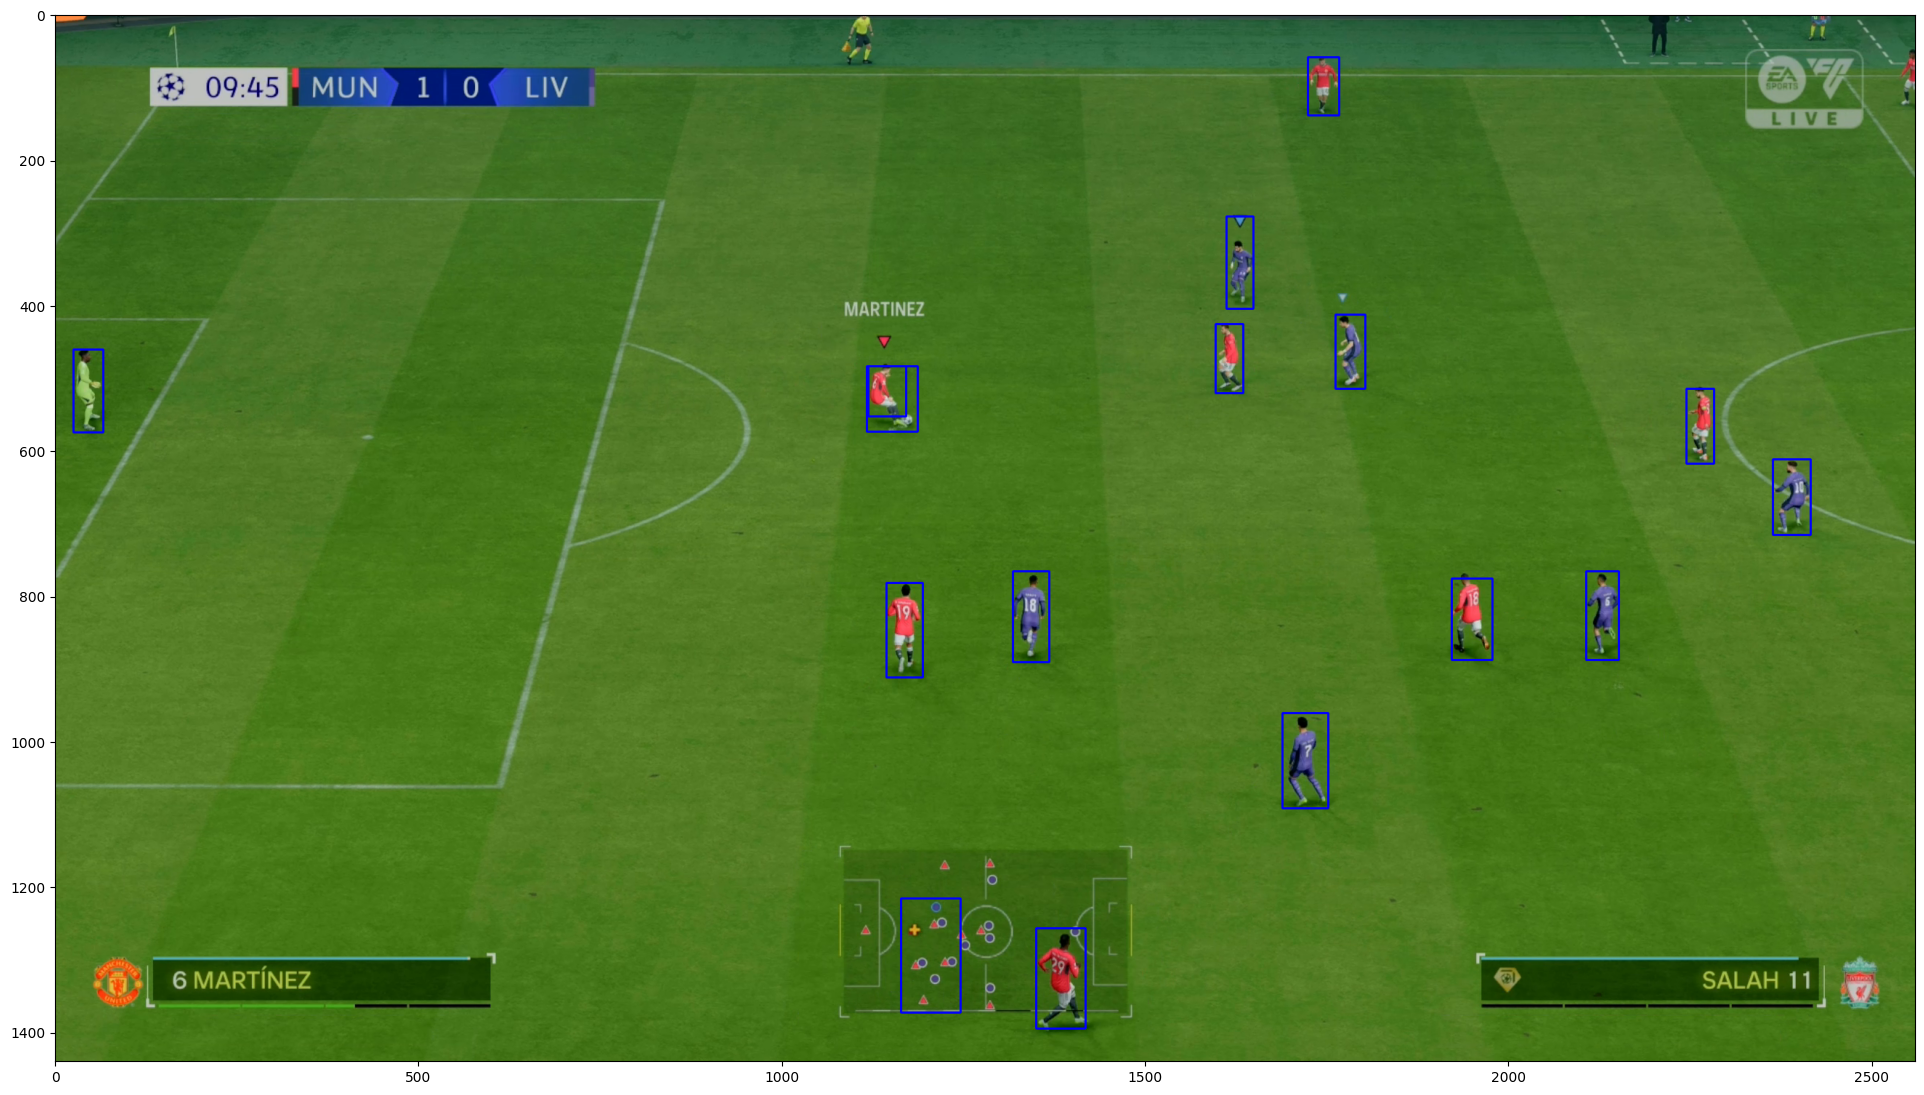

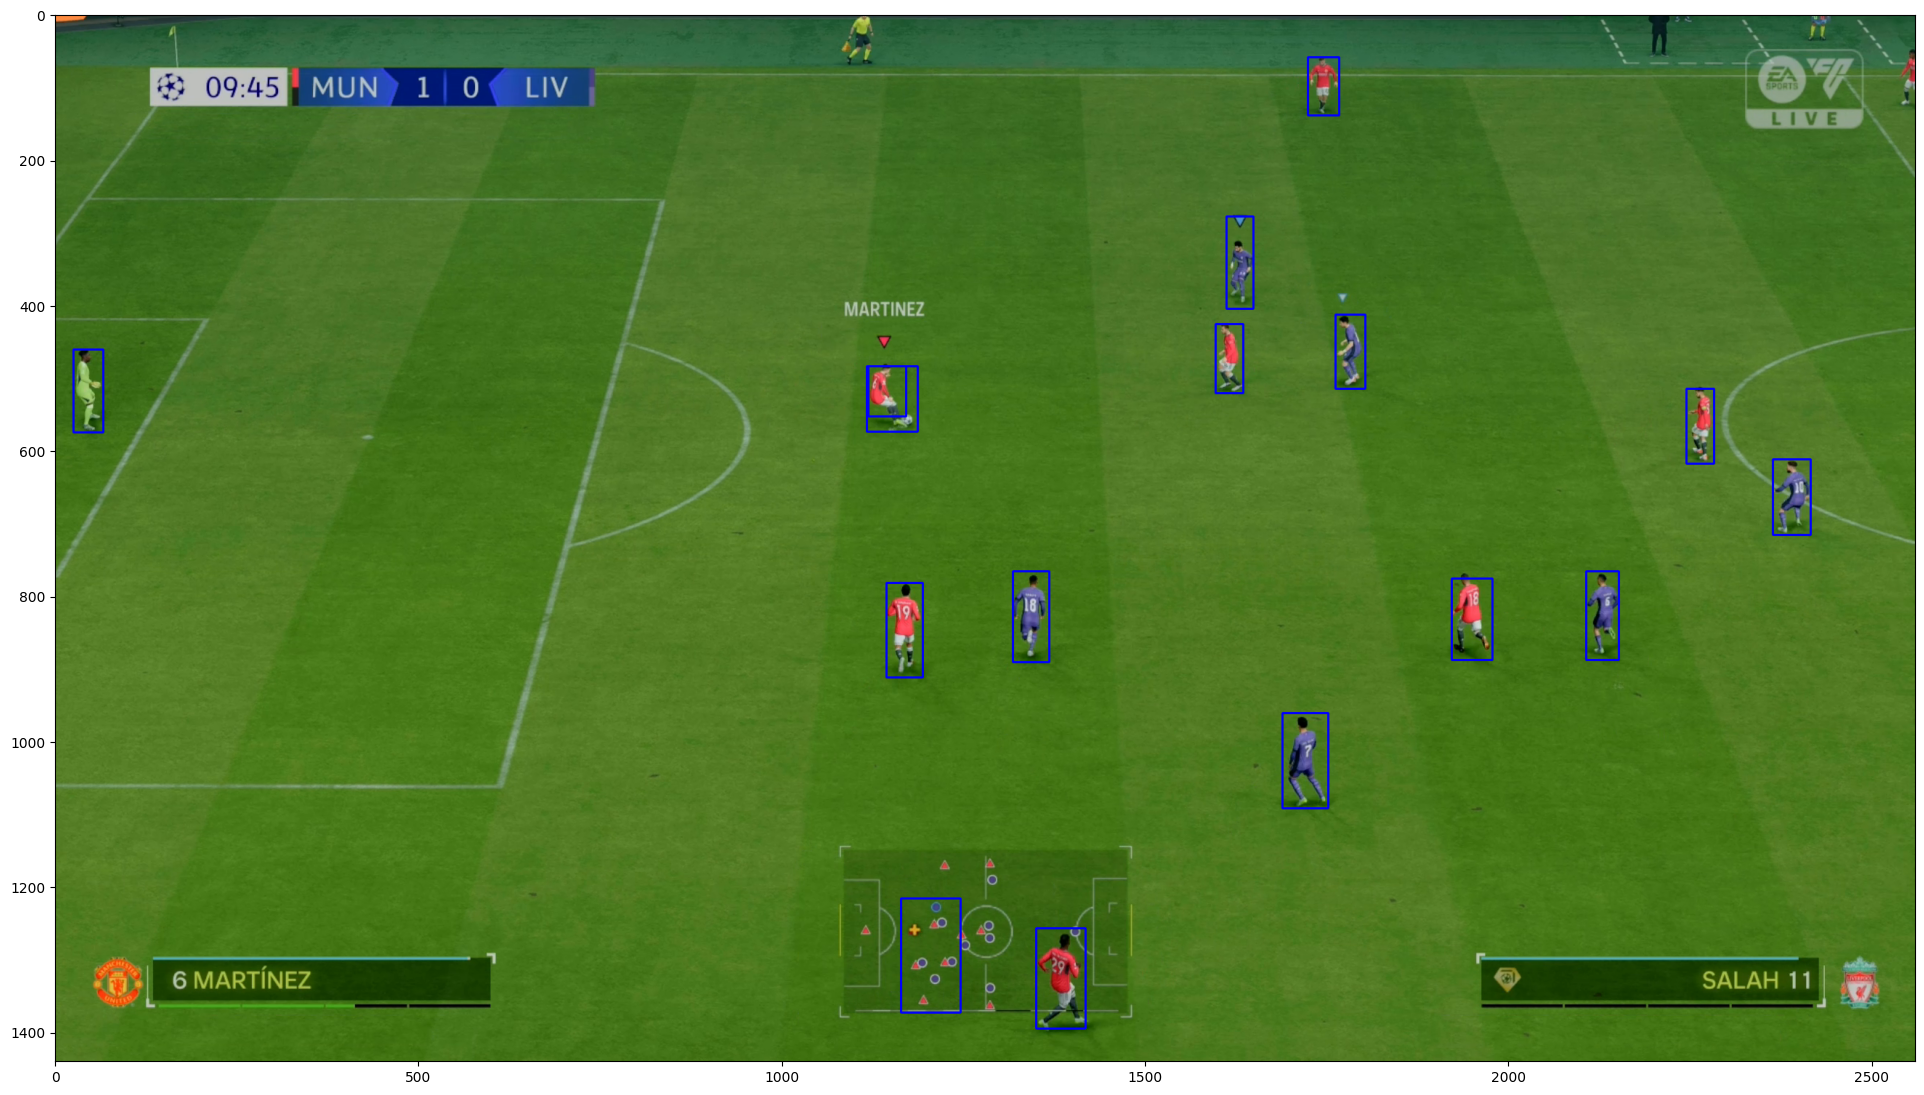

In [32]:
image = cv2.imread(os.path.join(images_path_2, '000000000090.png'), cv2.IMREAD_UNCHANGED)
rep_image = cv2.imread(os.path.join(dest_images_path, '000000000090.png'), cv2.IMREAD_UNCHANGED)

for annotation in annotation_list:
    bbox = annotation['bbox']
    startX, startY, w, h = bbox
    endX = startX + w
    endY = startY + h
    cv2.rectangle(image, (startX, startY), (endX, endY),
    				(255, 0, 0), 2)
    cv2.rectangle(rep_image, (startX, startY), (endX, endY),
    				(255, 0, 0), 2)

plt.figure()
plt.imshow(image[:,:,::-1])

plt.figure()
plt.imshow(rep_image[:,:,::-1])

In [26]:
image_list_1 = coco_1["images"]
image_list_2 = coco_2["images"]
image_name_list_1 = [i["file_name"] for i in image_list_1]
sorted(image_name_list_1)

['000000000001.png',
 '000000000002.png',
 '000000000003.png',
 '000000000004.png',
 '000000000005.png',
 '000000000056.png',
 '000000000058.png',
 '000000000080.png',
 '000000000084.png',
 '000000000107.png',
 '000000000126.png',
 '000000000128.png',
 '000000000132.png',
 '000000000138.png',
 '000000000144.png',
 '000000000186.png',
 '000000000187.png',
 '000000000188.png',
 '000000000189.png',
 '000000000201.png',
 '000000000204.png',
 '000000000205.png',
 '000000000209.png',
 '000000000215.png',
 '000000000216.png',
 '000000000222.png',
 '000000000225.png',
 '000000000226.png',
 '000000000242.png',
 '000000000243.png',
 '000000000246.png',
 '000000000256.png',
 '000000000257.png',
 '000000000286.png',
 '000000000287.png',
 '000000000295.png',
 '000000000296.png',
 '000000000297.png',
 '000000000332.png',
 '000000000333.png',
 '000000000356.png',
 '000000000379.png',
 '000000000380.png',
 '000000000381.png',
 '000000000382.png',
 '000000000383.png',
 '000000000384.png',
 '00000000038

In [29]:
sorted([i["file_name"] for i in image_list_1])

['000000000001.png',
 '000000000002.png',
 '000000000003.png',
 '000000000004.png',
 '000000000005.png',
 '000000000056.png',
 '000000000058.png',
 '000000000080.png',
 '000000000084.png',
 '000000000107.png',
 '000000000126.png',
 '000000000128.png',
 '000000000132.png',
 '000000000138.png',
 '000000000144.png',
 '000000000186.png',
 '000000000187.png',
 '000000000188.png',
 '000000000189.png',
 '000000000201.png',
 '000000000204.png',
 '000000000205.png',
 '000000000209.png',
 '000000000215.png',
 '000000000216.png',
 '000000000222.png',
 '000000000225.png',
 '000000000226.png',
 '000000000242.png',
 '000000000243.png',
 '000000000246.png',
 '000000000256.png',
 '000000000257.png',
 '000000000286.png',
 '000000000287.png',
 '000000000295.png',
 '000000000296.png',
 '000000000297.png',
 '000000000332.png',
 '000000000333.png',
 '000000000356.png',
 '000000000379.png',
 '000000000380.png',
 '000000000381.png',
 '000000000382.png',
 '000000000383.png',
 '000000000384.png',
 '00000000038

In [30]:
# Update image_name for second coco and move images from two dataset into destination folder
image_list_1 = coco_1["images"]
image_list_2 = coco_2["images"]
image_name_list_1 = [i["file_name"] for i in image_list_1]
for image_name_1 in image_name_list_1:
    image_path_1 = os.path.join(images_path_1, image_name_1)
    shutil.copy(image_path_1, os.path.join(dest_images_path, image_name_1))

for i in range(len(image_list_2)):
    image_list_2[i]["id"] = image_list_2[i]["id"] + len(image_list_1)
    # Change name of image in the 2nd coco json in case of duplication
    old_name = image_list_2[i]["file_name"]
    if image_list_2[i]["file_name"] in image_name_list_1:
        new_name = image_list_2[i]["file_name"].replace(".png","_dup.png")
        image_list_2[i]["file_name"] = new_name
    else:
        new_name = image_list_2[i]["file_name"]

    print(old_name, new_name)
    # Move images from 2nd coco dataset to new destination
    image_path_2 = os.path.join(images_path_2, old_name)
    shutil.copy(image_path_2, os.path.join(dest_images_path, new_name))
final_coco["images"] = sorted(image_list_1 + image_list_2, key=lambda x: x["id"])



000000000005.png 000000000005_dup.png
000000000006.png 000000000006.png
000000000009.png 000000000009.png
000000000019.png 000000000019.png
000000000023.png 000000000023.png
000000000035.png 000000000035.png
000000000036.png 000000000036.png
000000000037.png 000000000037.png
000000000038.png 000000000038.png
000000000039.png 000000000039.png
000000000064.png 000000000064.png
000000000065.png 000000000065.png
000000000066.png 000000000066.png
000000000067.png 000000000067.png
000000000086.png 000000000086.png
000000000090.png 000000000090.png
000000000107.png 000000000107_dup.png
000000000110.png 000000000110.png
000000000111.png 000000000111.png
000000000135.png 000000000135.png
000000000137.png 000000000137.png
000000000138.png 000000000138_dup.png
000000000165.png 000000000165.png
000000000243.png 000000000243_dup.png
000000000273.png 000000000273.png
000000000303.png 000000000303.png
000000000306.png 000000000306.png
000000000332.png 000000000332_dup.png
000000000368.png 00000000036

In [31]:
# Update annotations 
annotation_list_1 = coco_1["annotations"]
annotation_list_2 = coco_2["annotations"]
for i in range(len(annotation_list_2)):
    annotation_list_2[i]["image_id"] = annotation_list_2[i]["image_id"] + len(image_list_1)
    annotation_list_2[i]["id"] = annotation_list_2[i]["id"] + len(annotation_list_1) 
    
final_coco["annotations"] = sorted(annotation_list_1 + annotation_list_2, key=lambda x: x["id"])


with open(os.path.join(dest_coco_path, 'instances_default.json'), 'w') as f:
    json.dump(final_coco, f)